C:\Users\hp\AppData\Local\Temp\ipykernel_17112\1613377081.py:196: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.04, 1, 0.95])


Saved: gaze_heatmap.png


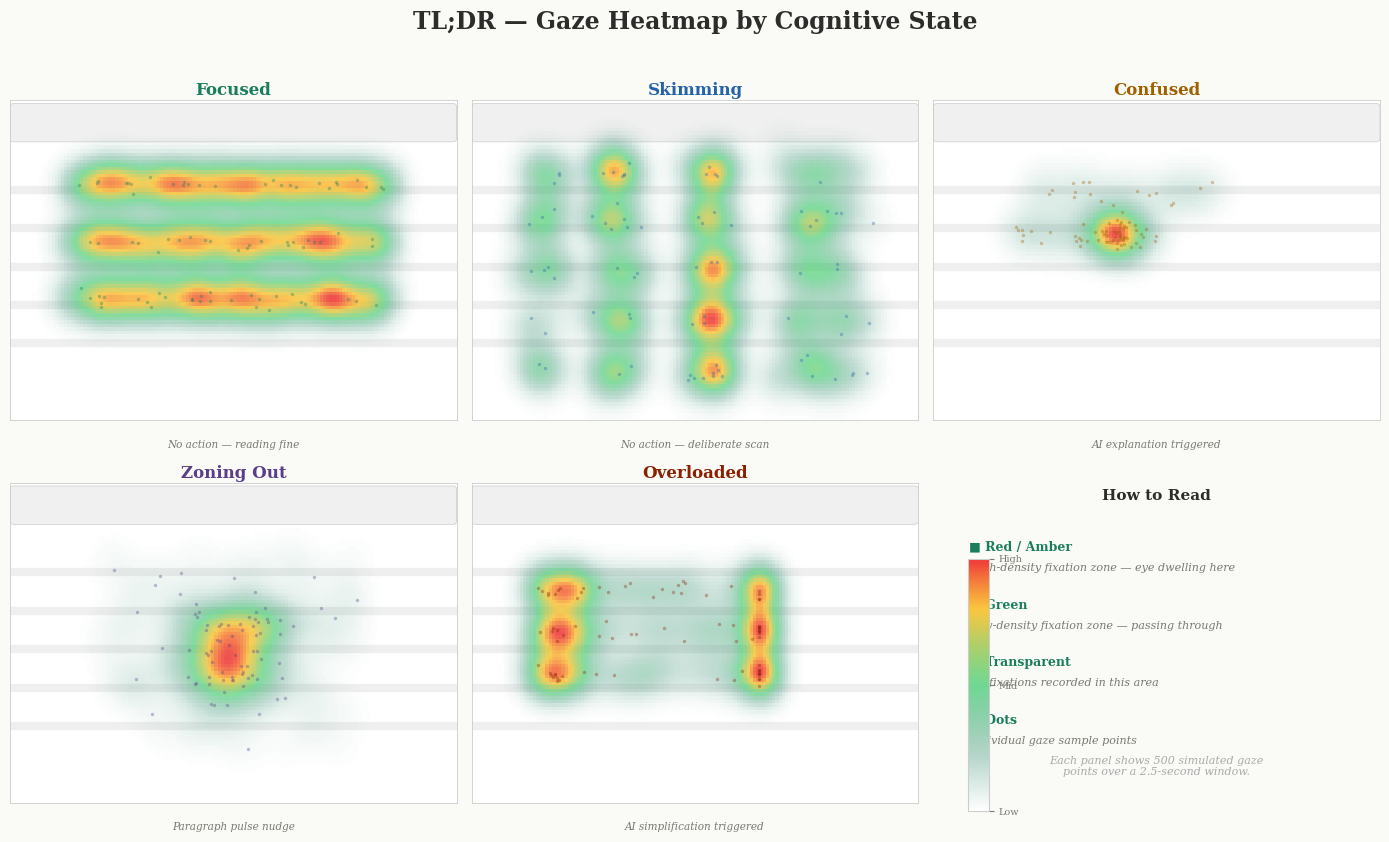

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import LinearSegmentedColormap
from scipy.ndimage import gaussian_filter

np.random.seed(42)

FIG_W, FIG_H = 14, 9
W, H = 1400, 900   # canvas resolution

# ── Custom colourmap: transparent → green (matches TL;DR brand) ─────────────
colors_g = [
    (0,   (0.098, 0.494, 0.365, 0.0)),   # #1A7E5D fully transparent
    (0.2, (0.098, 0.494, 0.365, 0.3)),
    (0.5, (0.196, 0.784, 0.392, 0.7)),   # mid green
    (0.8, (0.980, 0.749, 0.141, 0.88)),  # amber
    (1.0, (0.941, 0.220, 0.220, 1.0)),   # red-hot
]
cmap = LinearSegmentedColormap.from_list(
    'tldr_heat',
    [(p, c) for p, c in colors_g],
    N=256
)

# ── Simulated gaze data for FIVE cognitive states ────────────────────────────
def make_gaze(state, n=300):
    """Return (x_arr, y_arr) simulating gaze on a browser-like reading area."""
    if state == 'focused':
        pts = []
        for line_y in [240, 400, 560]:
            xs = np.linspace(200, 1180, n//3)
            ys = np.full(n//3, line_y) + np.random.normal(0, 12, n//3)
            pts.append(np.c_[xs + np.random.normal(0, 18, n//3), ys])
        return np.vstack(pts)
    elif state == 'skimming':
        pts = []
        for line_y in [200, 340, 480, 620, 760]:
            n_pts = n // 5
            xs = np.random.choice([220, 450, 750, 1050, 1180], n_pts,
                                   p=[0.15, 0.25, 0.30, 0.20, 0.10])
            xs = xs + np.random.normal(0, 40, n_pts)
            ys = np.full(n_pts, line_y) + np.random.normal(0, 20, n_pts)
            pts.append(np.c_[xs, ys])
        return np.vstack(pts)
    elif state == 'confused':
        cx, cy = 580, 380
        pts_cluster = np.random.normal([cx, cy], [45, 22], (n//2, 2))
        reg_xs = np.random.uniform(250, 700, n//4)
        reg_ys = np.full(n//4, cy) + np.random.normal(0, 15, n//4)
        prev_xs = np.random.uniform(300, 900, n//4)
        prev_ys = np.full(n//4, cy - 120) + np.random.normal(0, 18, n//4)
        return np.vstack([pts_cluster,
                          np.c_[reg_xs, reg_ys],
                          np.c_[prev_xs, prev_ys]])
    elif state == 'zoning_out':
        cx, cy = 680, 440
        pts_drift = np.random.normal([cx, cy + 80], [90, 60], (n//2, 2))
        pts_wander = np.column_stack([
            np.random.uniform(300, 1100, n//4),
            np.random.uniform(200, 750, n//4)
        ])
        pts_text = np.random.normal([720, 400], [120, 18], (n//4, 2))
        return np.vstack([pts_drift, pts_wander, pts_text])
    elif state == 'overloaded':
        pts = []
        for line_y in [300, 420, 540]:
            xs = np.cumsum(np.abs(np.random.normal(12, 8, n//5))) + 200
            xs = np.clip(xs, 200, 900)
            ys = np.full(len(xs), line_y) + np.random.normal(0, 14, len(xs))
            reg_xs = np.random.uniform(200, 350, n//10)
            reg_ys = np.full(n//10, line_y) + np.random.normal(0, 12, n//10)
            pts.append(np.c_[xs, ys])
            pts.append(np.c_[reg_xs, reg_ys])
        return np.vstack(pts)

STATES = ['focused', 'skimming', 'confused', 'zoning_out', 'overloaded']
TITLES = ['Focused', 'Skimming', 'Confused', 'Zoning Out', 'Overloaded']
ACTIONS = [
    'No action — reading fine',
    'No action — deliberate scan',
    'AI explanation triggered',
    'Paragraph pulse nudge',
    'AI simplification triggered',
]
COLORS_ACCENT = ['#1A7E5D','#2563a8','#a06000','#5a3e8a','#8b2000']

# ── Layout: 2 rows, 3 cols (5 panels + 1 legend) ────────────────────────────
fig = plt.figure(figsize=(FIG_W, FIG_H), facecolor='#FAFAF7')
fig.suptitle("TL;DR — Gaze Heatmap by Cognitive State",
             fontsize=17, fontweight='bold', color='#2C2C2A',
             fontfamily='serif', y=0.97)

axes = []
positions = [(0,0),(0,1),(0,2),(1,0),(1,1)]

for idx, (row, col) in enumerate(positions):
    ax = fig.add_subplot(2, 3, idx+1)
    axes.append(ax)

ax_legend = fig.add_subplot(2, 3, 6)

# ── Draw each heatmap ────────────────────────────────────────────────────────
def draw_browser_chrome(ax):
    """Minimal simulated browser UI background."""
    ax.set_facecolor('#FFFFFF')
    ax.add_patch(mpatches.FancyBboxPatch(
        (0.01, 0.88), 0.98, 0.10, transform=ax.transAxes,
        boxstyle="round,pad=0.01", facecolor='#F0F0F0',
        edgecolor='#CCCCCC', linewidth=0.5, zorder=1))
    for line_frac in [0.72, 0.60, 0.48, 0.36, 0.24]:
        ax.axhline(y=line_frac * H, color='#E0E0E0',
                   linewidth=6, alpha=0.5, zorder=1)

for idx, state in enumerate(STATES):
    ax = axes[idx]
    draw_browser_chrome(ax)

    pts = make_gaze(state, n=500)
    pts[:, 0] = np.clip(pts[:, 0], 0, W-1)
    pts[:, 1] = np.clip(pts[:, 1], 0, H-1)

    heatmap, _, _ = np.histogram2d(pts[:, 0], H - pts[:, 1],
                                    bins=[140, 90],
                                    range=[[0, W], [0, H]])
    heatmap = gaussian_filter(heatmap.T, sigma=4.5)
    heatmap = heatmap / heatmap.max()

    extent = [0, W, 0, H]
    ax.imshow(heatmap, extent=extent, origin='lower',
              cmap=cmap, alpha=0.88, aspect='auto', zorder=2,
              vmin=0.0, vmax=1.0)

    sample = pts[np.random.choice(len(pts), min(80, len(pts)), replace=False)]
    ax.scatter(sample[:, 0], H - sample[:, 1],
               s=6, c=COLORS_ACCENT[idx], alpha=0.35,
               linewidths=0, zorder=3)

    ax.set_title(TITLES[idx], fontsize=12, fontweight='bold',
                 color=COLORS_ACCENT[idx], fontfamily='serif', pad=4)

    ax.text(0.5, -0.06, ACTIONS[idx], transform=ax.transAxes,
            fontsize=7.5, ha='center', va='top', color='#7a7a72',
            fontstyle='italic', fontfamily='serif')

    ax.set_xlim(0, W)
    ax.set_ylim(0, H)
    ax.set_xticks([]); ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_edgecolor('#CCCCCC')
        spine.set_linewidth(0.6)

# ── Legend panel ─────────────────────────────────────────────────────────────
ax_legend.set_facecolor('#FAFAF7')
ax_legend.axis('off')

ax_legend.text(0.5, 0.98, 'How to Read',
               transform=ax_legend.transAxes,
               fontsize=11, fontweight='bold', ha='center', va='top',
               color='#2C2C2A', fontfamily='serif')

legend_items = [
    ('Red / Amber', 'High-density fixation zone — eye dwelling here'),
    ('Green',       'Low-density fixation zone — passing through'),
    ('Transparent', 'No fixations recorded in this area'),
    ('Dots',        'Individual gaze sample points'),
]
y = 0.82
for label, desc in legend_items:
    ax_legend.text(0.08, y, f"■ {label}", transform=ax_legend.transAxes,
                   fontsize=9, va='top', color='#1A7E5D', fontfamily='serif',
                   fontweight='bold')
    ax_legend.text(0.08, y - 0.07, desc, transform=ax_legend.transAxes,
                   fontsize=8, va='top', color='#7a7a72', fontfamily='serif',
                   fontstyle='italic')
    y -= 0.18

ax_legend.text(0.5, 0.08,
    'Each panel shows 500 simulated gaze\npoints over a 2.5-second window.',
    transform=ax_legend.transAxes, fontsize=8,
    ha='center', va='bottom', color='#aaaaaa', fontfamily='serif',
    fontstyle='italic')

# Add colourbar
cbar_ax = fig.add_axes([0.695, 0.08, 0.015, 0.28])
sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(0, 1))
sm.set_array([])
cb = fig.colorbar(sm, cax=cbar_ax)
cb.set_ticks([0, 0.5, 1.0])
cb.set_ticklabels(['Low', 'Mid', 'High'], fontsize=7, fontfamily='serif')
cb.ax.yaxis.set_tick_params(color='#7a7a72')
plt.setp(cb.ax.yaxis.get_ticklabels(), color='#7a7a72')
cb.outline.set_edgecolor('#CCCCCC')

# FIXED: Removed hspace and wspace arguments
plt.tight_layout(rect=[0, 0.04, 1, 0.95])

plt.savefig('gaze_heatmap.png', bbox_inches='tight', dpi=140)
print("Saved: gaze_heatmap.png")